# 06 — A more detailed EDA diagnostic for data artifacts

This notebook does a focused EDA pass to look for those artifacts and then re-runs the Random Forest classifier on the cleaned feature set to see whether performance improves.

**Sections:**

1. Setup
2. Per-feature outlier detection (Q3 + 1.5·IQR rule, as in Emiliya slide 8)
3. Skewness and log-transform candidates
4. Per-plate descriptive statistics — within-drug across-plate comparison
5. Feature correlation matrix (collinearity check)
6. Re-train the Random Forest on cleaned + log-transformed features
7. Summary

Outputs go to `outputs/figures/` and `outputs/tables/`.


## 1. Setup

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy.stats import skew

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
FIGURES = PROJECT_ROOT / "outputs" / "figures"
TABLES  = PROJECT_ROOT / "outputs" / "tables"
for d in (FIGURES, TABLES):
    d.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(DATA_PROCESSED / "df_clean_wide.csv")
mapping = pd.DataFrame({
    "Metadata_JCP2022": ["JCP2022_033924", "JCP2022_095995", "JCP2022_001418", "JCP2022_094347", "JCP2022_051785"],
    "drug_name":        ["DMSO", "hydroxyurea", "palbociclib", "etoposide", "resveratrol"],
})
df = df.merge(mapping, on="Metadata_JCP2022", how="left")
# Apply Emiliya's 3-stage filter (same as previous notebooks)
df = df[
    (df["Cells_AreaShape_FormFactor"] <= 1)   & (df["Nuclei_AreaShape_FormFactor"] <= 1) &
    (df["Cells_AreaShape_EulerNumber"] == 1)  & (df["Nuclei_AreaShape_EulerNumber"] == 1) &
    (df["NC_Ratio"] <= 1)                     & (df["NC_Ratio_Radius"] <= 1)
].copy()

FEATURES = [
    "Cells_AreaShape_BoundingBoxArea",  "Cells_AreaShape_Compactness",
    "Cells_AreaShape_Eccentricity",     "Cells_AreaShape_FormFactor",
    "Cells_AreaShape_MeanRadius",       "Cells_AreaShape_Perimeter",
    "Cells_AreaShape_Solidity",
    "Nuclei_AreaShape_BoundingBoxArea", "Nuclei_AreaShape_Compactness",
    "Nuclei_AreaShape_Eccentricity",    "Nuclei_AreaShape_FormFactor",
    "Nuclei_AreaShape_MeanRadius",      "Nuclei_AreaShape_Perimeter",
    "Nuclei_AreaShape_Solidity",
    "NC_Ratio",                         "NC_Ratio_Radius",
]
DRUG_ORDER  = ["DMSO", "hydroxyurea", "palbociclib", "etoposide", "resveratrol"]
DRUG_COLORS = {"DMSO": "#666666", "hydroxyurea": "#D4A017", "palbociclib": "#FF7F0E",
               "etoposide": "#D81B82", "resveratrol": "#D62728"}
sns.set_theme(style="whitegrid")
print(f"Cells after Emiliya filter: {len(df):,}")


Cells after Emiliya filter: 102,430


## 2. Per-feature outlier detection (Q3 + 1.5*IQR)

Firstly make outlier diagnostic, and use the common (Q3+1.5IQR) to detect. We compute the fraction of cells flagged as outliers per feature and visualize boxplots colored by drug. Features with a large percentage of outliers, or where outliers cluster on a specific drug, are candidates for stricter filtering or transformation.

In [23]:
# Here we compute the outlier statistics per feature
outlier_rows = []
for feat in FEATURES:
    q1, q3 = df[feat].quantile([0.25, 0.75])
    iqr = q3 - q1
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    mask = (df[feat] < lo) | (df[feat] > hi)
    outlier_rows.append({
        "feature": feat,
        "Q1": q1, "Q3": q3, "IQR": iqr,
        "lower_fence": lo, "upper_fence": hi,
        "#_outliers": int(mask.sum()),
        "%_outliers": mask.mean() * 100,
    })

outlier_df = pd.DataFrame(outlier_rows).sort_values("%_outliers", ascending=False)
outlier_df.to_csv(TABLES / "outlier_summary.csv", index=False)
outlier_df.round(3)


,feature,Q1,Q3,IQR,lower_fence,upper_fence,#_outliers,%_outliers
8,Nuclei_AreaShape_Compactness,1.171,1.468,0.296,0.727,1.912,16222,15.837
13,Nuclei_AreaShape_Solidity,0.909,0.963,0.054,0.829,1.044,15225,14.864
10,Nuclei_AreaShape_FormFactor,0.681,0.854,0.172,0.423,1.112,13218,12.904
11,Nuclei_AreaShape_MeanRadius,2.839,3.512,0.673,1.830,4.521,10168,9.927
14,NC_Ratio,0.137,0.266,0.129,-0.056,0.459,10040,9.802
12,Nuclei_AreaShape_Perimeter,66.400,83.166,16.765,41.252,108.314,9715,9.485
4,Cells_AreaShape_MeanRadius,4.235,5.734,1.499,1.986,7.983,6612,6.455
15,NC_Ratio_Radius,0.564,0.732,0.168,0.312,0.983,5876,5.737
1,Cells_AreaShape_Compactness,2.070,2.968,0.898,0.723,4.315,5204,5.081
7,Nuclei_AreaShape_BoundingBoxArea,381.518,581.360,199.843,81.754,881.124,5024,4.905


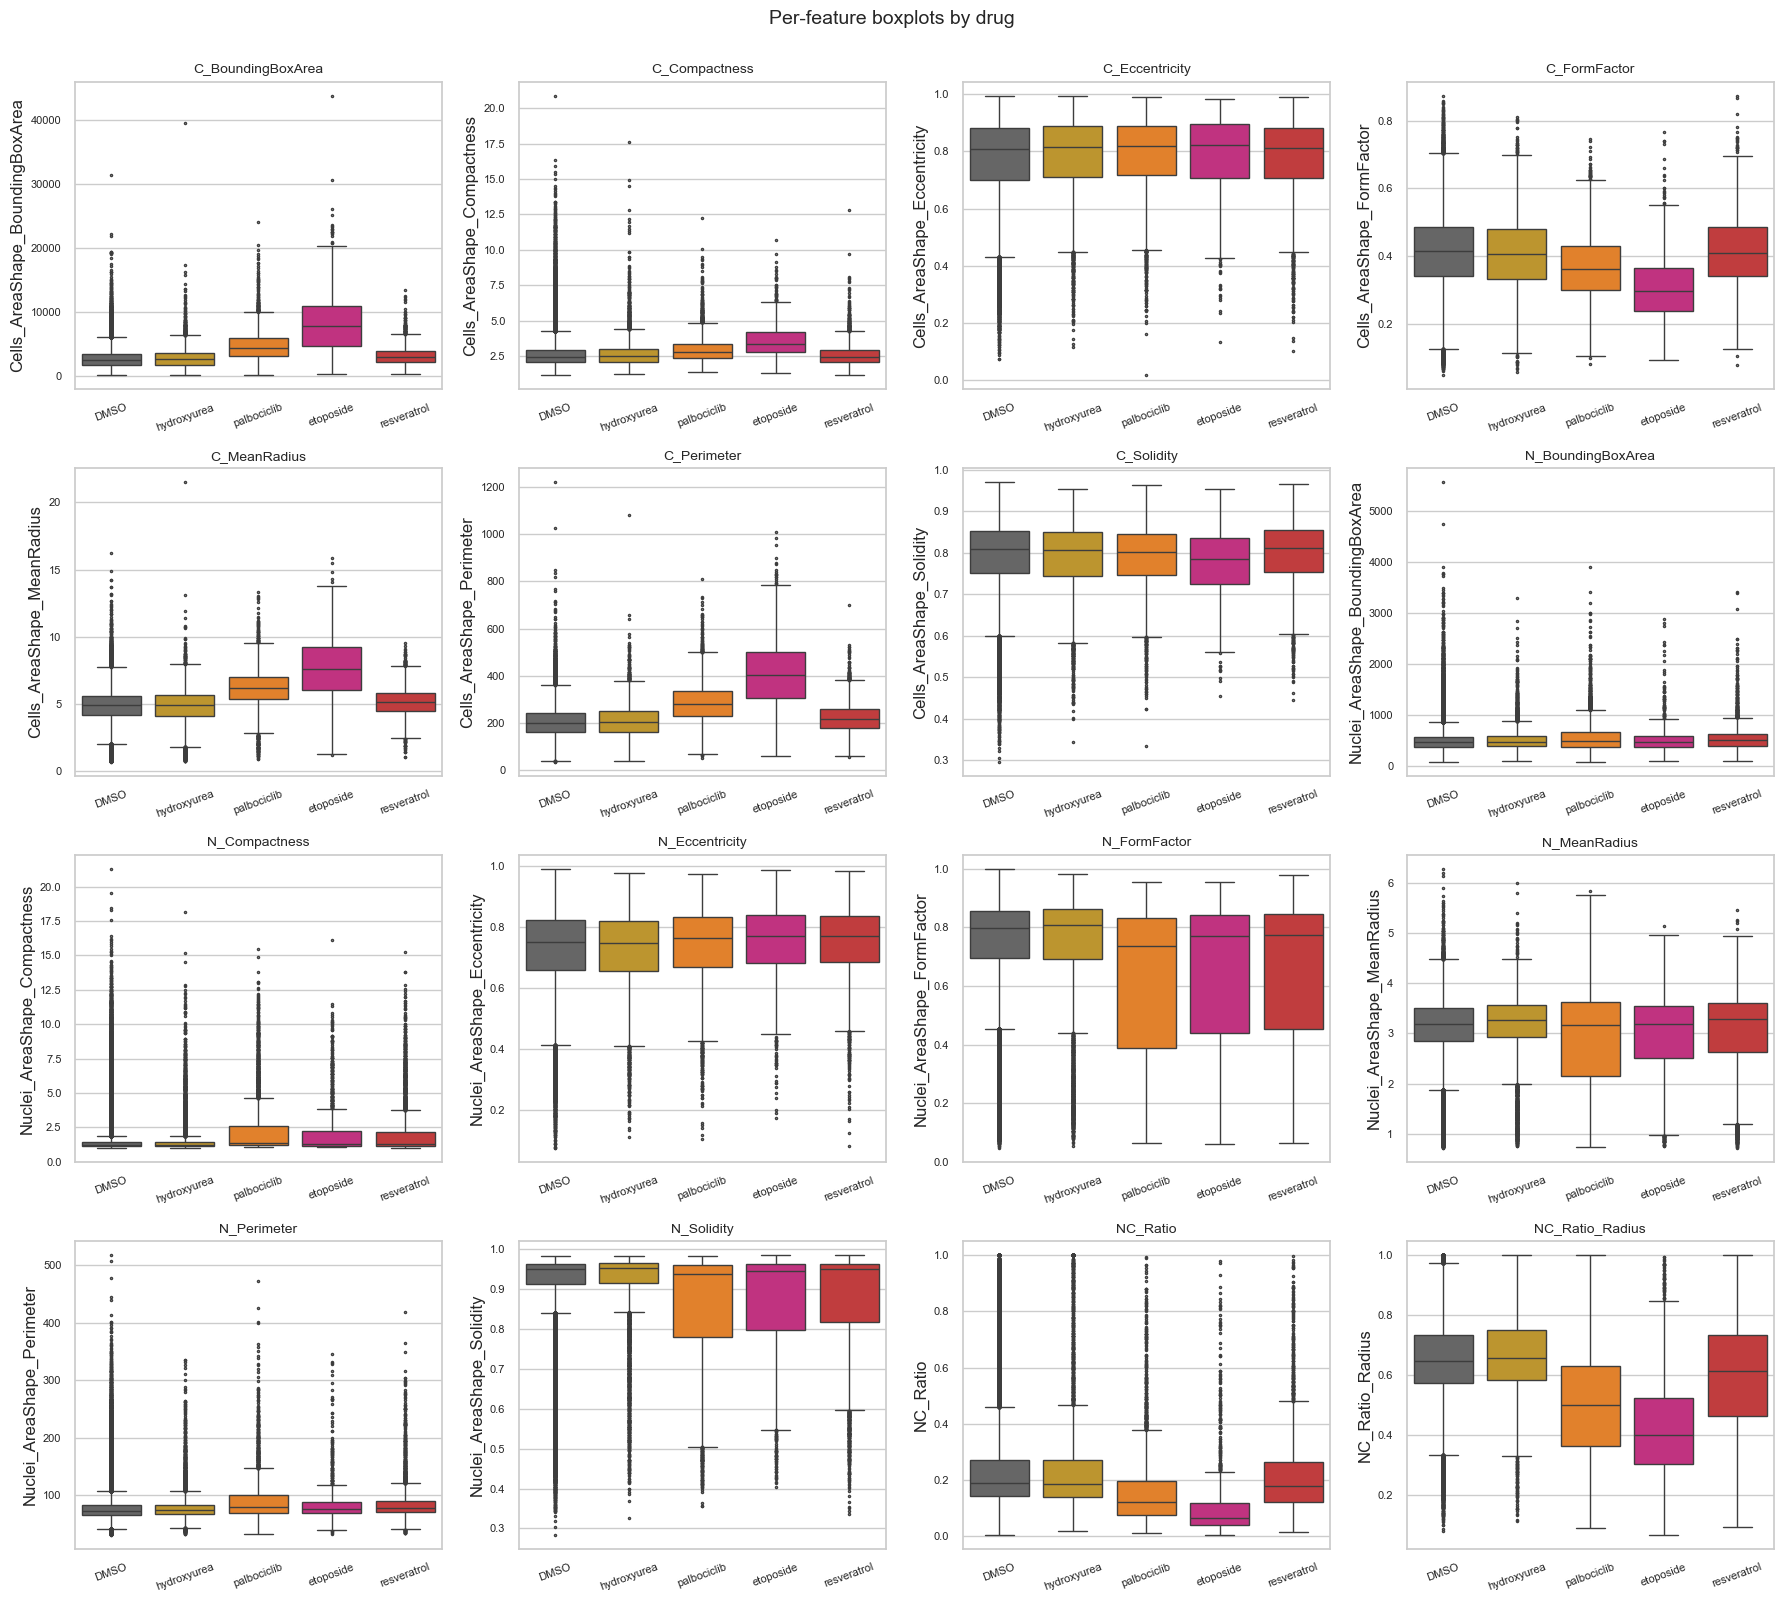

In [22]:
# Boxplots per feature, colored by drug
fig, axes = plt.subplots(4, 4, figsize=(18, 16))
axes = axes.flatten()
for ax, feat in zip(axes, FEATURES):
    sns.boxplot(
        data=df, x="drug_name", y=feat,
        order=DRUG_ORDER, palette=DRUG_COLORS, hue="drug_name", legend=False,
        ax=ax, fliersize=1.5,
    )
    ax.set_title(feat.replace("_AreaShape_", "_").replace("Cells_", "C_").replace("Nuclei_", "N_"), fontsize=10)
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=20, labelsize=8)
    ax.tick_params(axis="y", labelsize=8)

fig.suptitle("Per-feature boxplots by drug", fontsize=14, y=1.0)
plt.tight_layout()
fig.savefig(FIGURES / "boxplots_per_feature.png", dpi=180, bbox_inches="tight")
plt.show()


The whiskers extend to the last value inside Q3 + 1.5·IQR; dots beyond are flagged outliers. Features with many outliers per drug indicate heavy tails that may be confusing the classifier. Particularly, Etoposide and Palbociclib show larger cell-size distributions than DMSO, especially in cell area, mean radius, and perimeter. In contrast, nucleus-size features show weaker shifts, suggesting that cell enlargement is not matched by proportional nucleus enlargement. This is consistent with the lower N/C ratio observed for etoposide and palbociclib. Many features also show long tails and numerous outliers, indicating that skewness and potential artifacts should be considered before interpreting classifier performance.

## 3. Skewness and log-transform candidates

For each feature, we then compute the skewness statistic:
 * Values near 0 are symmetric (normal-like).
 * Values > 0 are right-skewed.
 * Values << 0 are left-skewed.

As a rule of thumb:
- |skew| < 0.5 is approximately symmetric
- 0.5 <= |skew| < 1 is moderately skewed
- |skew| >= 1 are highly skewed, we may apply a log-transformation


In [25]:
# Compute skewness per feature
skew_rows = []
for feat in FEATURES:
    s = skew(df[feat].dropna())

    # Check conditions for wether we need to apply a log transformation
    needs_log = (s >= 1.0) and (df[feat].min() > 0)
    skew_rows.append({
        "feature": feat,
        "skewness": s,
        "min": df[feat].min(),
        "max": df[feat].max(),
        "log_transform_candidate": needs_log,
    })

skew_df = pd.DataFrame(skew_rows).sort_values("skewness", key=abs, ascending=False)
skew_df.to_csv(TABLES / "skewness_summary.csv", index=False)
skew_df.round(3)


,feature,skewness,min,max,log_transform_candidate
12,Nuclei_AreaShape_Perimeter,3.752,31.608,517.202,True
8,Nuclei_AreaShape_Compactness,3.681,1.000,21.295,True
1,Cells_AreaShape_Compactness,3.300,1.144,20.889,True
7,Nuclei_AreaShape_BoundingBoxArea,3.222,93.372,5560.522,True
0,Cells_AreaShape_BoundingBoxArea,2.489,112.385,43798.040,True
14,NC_Ratio,2.420,0.006,1.000,True
13,Nuclei_AreaShape_Solidity,-2.354,0.284,0.985,False
10,Nuclei_AreaShape_FormFactor,-1.571,0.047,1.000,False
5,Cells_AreaShape_Perimeter,1.164,36.919,1219.775,True
6,Cells_AreaShape_Solidity,-1.147,0.296,0.971,False


Log-transform candidates: 7 features
['Nuclei_AreaShape_Perimeter', 'Nuclei_AreaShape_Compactness', 'Cells_AreaShape_Compactness', 'Nuclei_AreaShape_BoundingBoxArea', 'Cells_AreaShape_BoundingBoxArea', 'NC_Ratio', 'Cells_AreaShape_Perimeter']


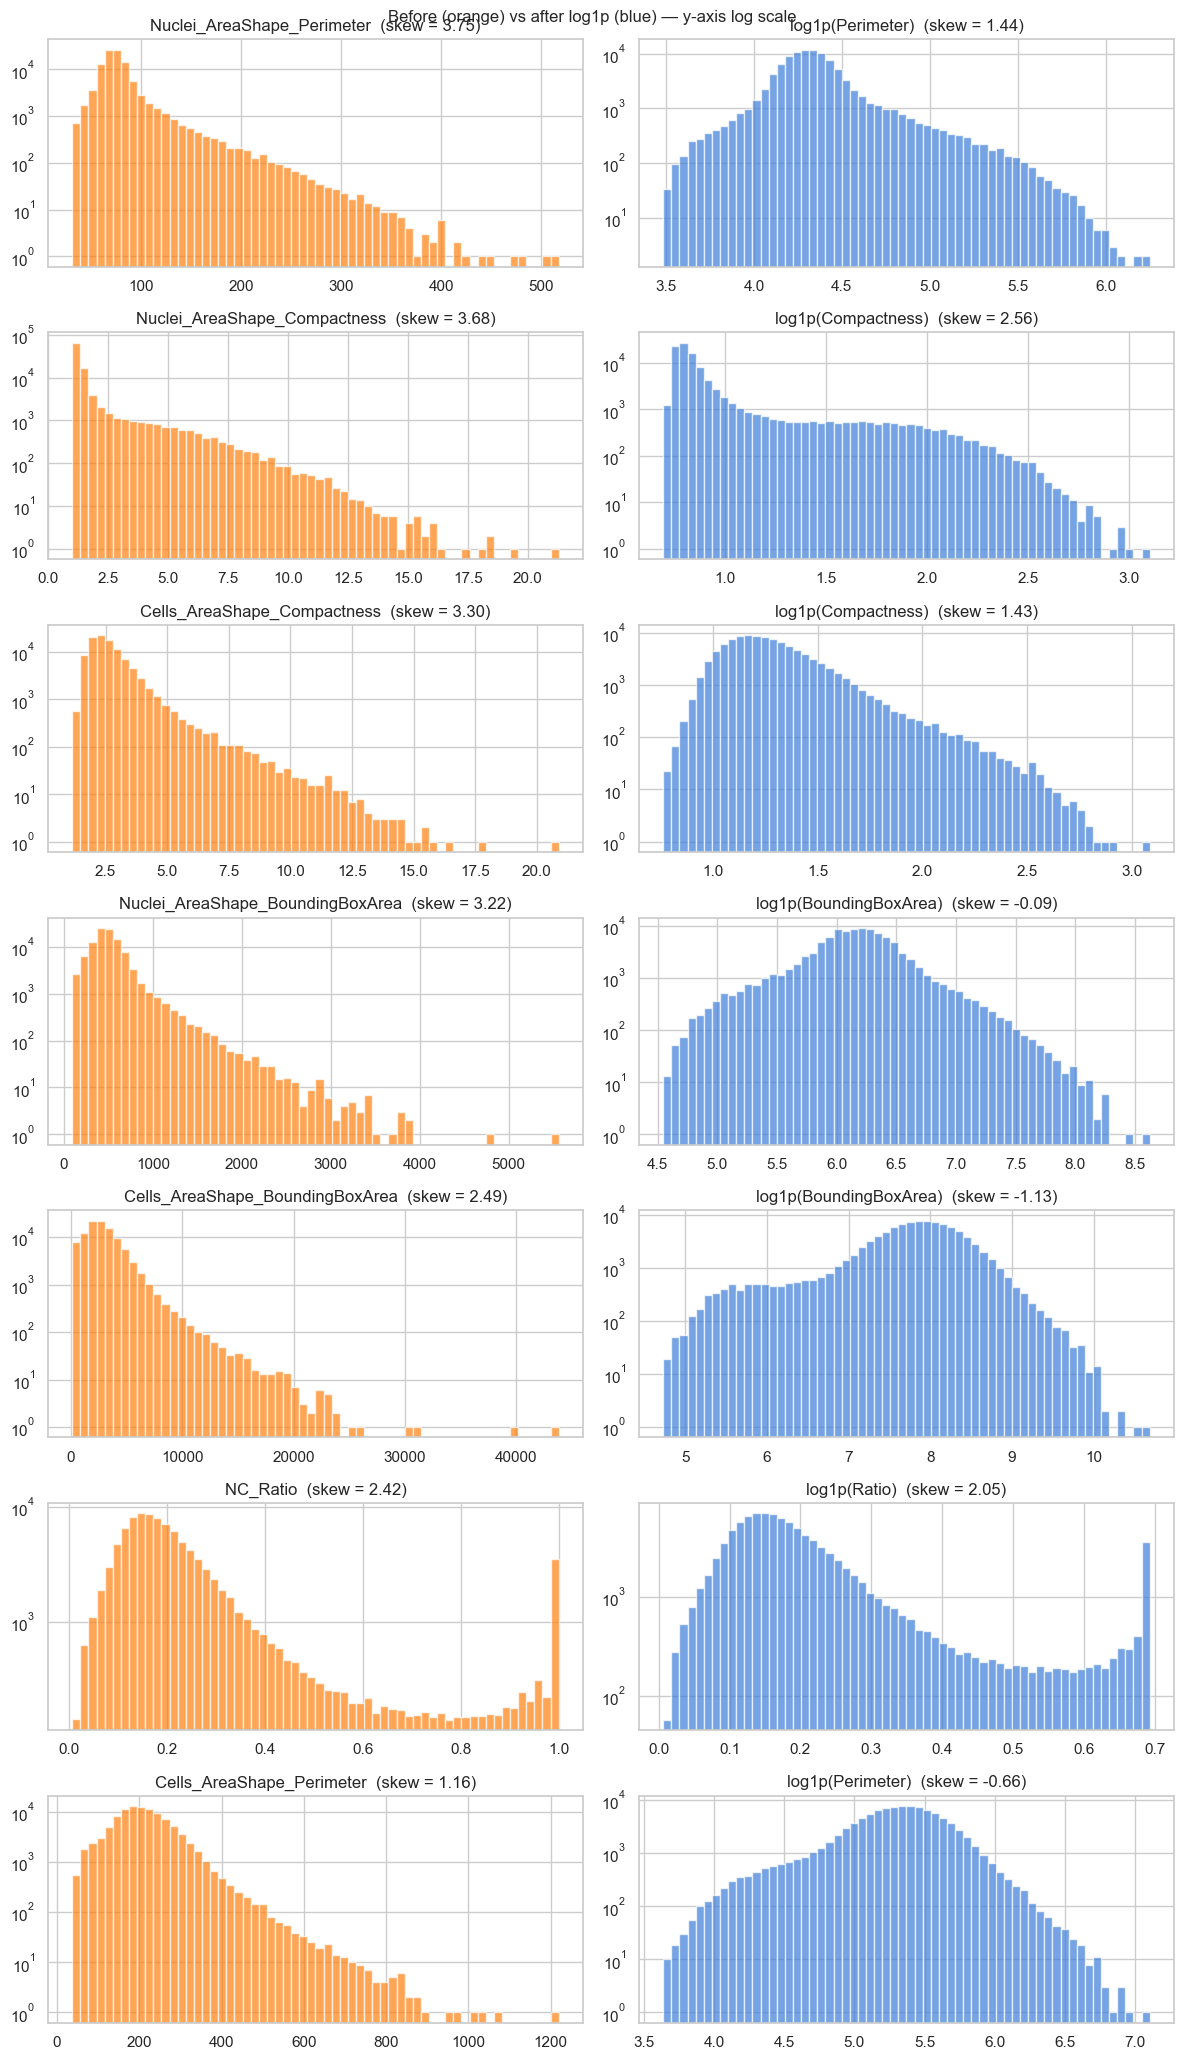

In [28]:
# For each highly skewed feature: show original vs log-transformed histogram
log_candidates = skew_df[skew_df["log_transform_candidate"]]["feature"].tolist()
print(f"Log-transform candidates: {len(log_candidates)} features")
print(log_candidates)

if log_candidates:
    n = len(log_candidates)
    fig, axes = plt.subplots(n, 2, figsize=(12, 3 * n))
    if n == 1:
        axes = axes.reshape(1, -1)
    for i, feat in enumerate(log_candidates):
        # Original
        axes[i, 0].hist(df[feat], bins=60, color="#FF7F0E", alpha=0.7)
        axes[i, 0].set_title(f"{feat}  (skew = {skew(df[feat]):.2f})")
        axes[i, 0].set_yscale("log")  # log y to see tails
        # Log-transformed
        axes[i, 1].hist(np.log1p(df[feat]), bins=60, color="#3B7DD8", alpha=0.7)
        axes[i, 1].set_title(f"log1p({feat.split('_')[-1]})  (skew = {skew(np.log1p(df[feat])):.2f})")
        axes[i, 1].set_yscale("log")
    fig.suptitle("Before (orange) vs after log1p (blue) — y-axis log scale", fontsize=12)
    plt.tight_layout()
    fig.savefig(FIGURES / "log_transform_check.png", dpi=180, bbox_inches="tight")
    plt.show()


The left orange panels are originial data, and the right is the log-transformed data, which should be looked like more symmetric compare to the original one. We use `log1p` (= log(x+1)) instead of plain log to handle any zeros gracefully.

Note: Although AreaShape are all shows a right-skewed, we may not simply apply a log transformation on that, becasue this may come from the natural set of cell. 

Note2: For N/C ratio, maybe use Logit transformation is a more natual way?


## 4. Plate within-drug comparison

We want to compare whether there are differences between different plates to determine whether the same drug will produce different effects on different plates. Ideally, for the same drug, cells from different culture dishes should exhibit similar morphological characteristics and distribution. However, if significant differences are observed, it means we cannot directly treat the cells from two culture dishes as independent experiments; we must also consider the environmental influences of the culture dishes.

- **hydroxyurea**: 3 plates (`CP1-SC1-21`, `CP2-SC1-02`, `CP2-SC1-21`)
- **palbociclib**: 2 plates (`CP1-SC1-18`, `CP2-SC1-18`)
- **etoposide**: 2 plates (`CP1-SC1-01`, `CP2-SC1-01`)
- **resveratrol**: 2 plates (`CP1-SC1-01`, `CP2-SC1-01`)

If a drug's distribution shifts systematically across plates, we have evidence of a plate effect.

Drugs on more than one plate: ['etoposide', 'hydroxyurea', 'palbociclib', 'resveratrol']


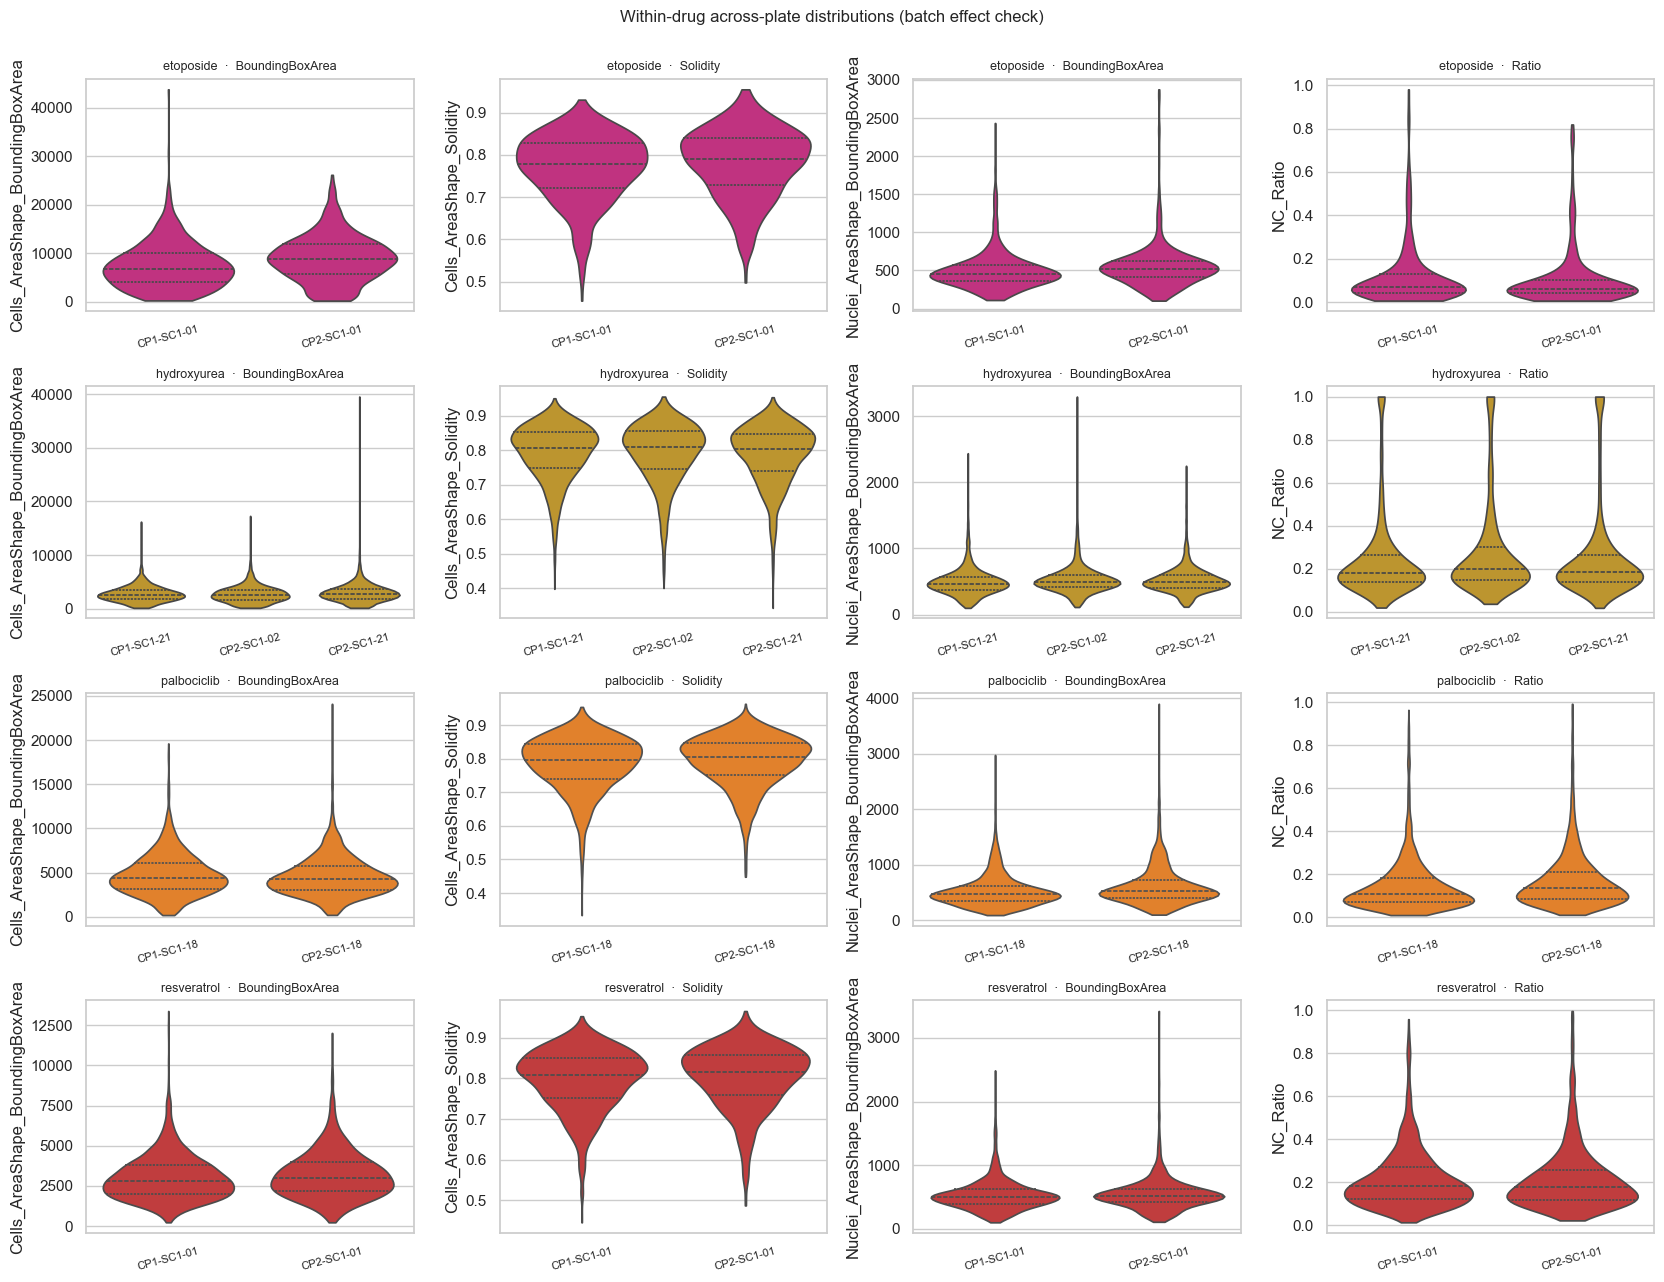

In [30]:
# For each drug with >1 plate, show distribution of 4 key features per plate
multi_plate_drugs = (df.groupby("drug_name")["Metadata_Plate"].nunique() > 1)
multi_plate_drugs = multi_plate_drugs[multi_plate_drugs].index.tolist()
print(f"Drugs on more than one plate: {multi_plate_drugs}")

key_features = [
    "Cells_AreaShape_BoundingBoxArea",
    "Cells_AreaShape_Solidity",
    "Nuclei_AreaShape_BoundingBoxArea",
    "NC_Ratio",
]

fig, axes = plt.subplots(len(multi_plate_drugs), len(key_features),
                         figsize=(4.2 * len(key_features), 3.2 * len(multi_plate_drugs)))
if len(multi_plate_drugs) == 1:
    axes = axes.reshape(1, -1)

for i, drug in enumerate(multi_plate_drugs):
    sub = df[df["drug_name"] == drug]
    for j, feat in enumerate(key_features):
        sns.violinplot(data=sub, x="Metadata_Plate", y=feat, ax=axes[i, j],
                       inner="quartile", cut=0, color=DRUG_COLORS[drug])
        axes[i, j].set_title(f"{drug}  ·  {feat.split('_')[-1]}", fontsize=9)
        axes[i, j].set_xlabel("")
        axes[i, j].tick_params(axis="x", rotation=15, labelsize=8)

        

fig.suptitle("Within-drug across-plate distributions (batch effect check)", fontsize=12, y=1.0)
plt.tight_layout()
fig.savefig(FIGURES / "per_plate_within_drug.png", dpi=180, bbox_inches="tight")
plt.show()


If the violins for the same drug look broadly similar across plates, plate-to-plate technical variation is small for that drug. If they shift visibly (e.g. same drug looks larger on plate A than plate B), that's a batch effect that the classifier will partly learn instead of learning the biological signal.

The cell area of etoposide shows a significant shift across different plates, suggesting that the cell-size signal of etoposide may be affected by plate/batch variation.

Hydroxyurea exhibits relatively stable distribution across multiple plates, with a relatively weak plate effect, particularly in terms of solidity. There is a slight shift in cell area and N/C ratio, but this is significantly less than the cell area shift observed in etoposide.

The cell area of palbociclib is relatively stable on both plates, but the nucleus area and N/C ratio show significant plate shift. This suggests that the nucleus-related features of palbociclib may be affected by plate-level variation.

There is suggestive evidence of plate-level variation for some drug-feature combinations, especially etoposide cell area and palbociclib nucleus/N-C ratio features. This should be considered when interpreting classifier performance.

In [35]:
# --- Additiona: cell counts per drug-plate ---
plate_counts = (
    df.groupby(["drug_name", "Metadata_Plate"])
      .size()
      .reset_index(name="n_cells")
      .sort_values(["drug_name", "Metadata_Plate"])
)

print("Cell counts per drug and plate:")
display(plate_counts)

plate_counts.to_csv(TABLES / "plate_counts_by_drug_plate.csv", index=False)

Cell counts per drug and plate:


,drug_name,Metadata_Plate,n_cells
0,DMSO,CP1-SC1-18,86012
1,etoposide,CP1-SC1-01,650
2,etoposide,CP2-SC1-01,583
3,hydroxyurea,CP1-SC1-21,2261
4,hydroxyurea,CP2-SC1-02,2160
5,hydroxyurea,CP2-SC1-21,2165
6,palbociclib,CP1-SC1-18,2435
7,palbociclib,CP2-SC1-18,2273
8,resveratrol,CP1-SC1-01,2068
9,resveratrol,CP2-SC1-01,1823


Well-level summary:


,Metadata_Plate,Metadata_Well,drug_name,n_cells,Cells_AreaShape_BoundingBoxArea_median,Cells_AreaShape_Solidity_median,Nuclei_AreaShape_BoundingBoxArea_median,NC_Ratio_median
0,CP1-SC1-01,C06,etoposide,650,6813.44625,0.778929,453.3425,0.069262
1,CP1-SC1-01,J12,resveratrol,2068,2804.97750,0.809640,502.3525,0.181587
2,CP1-SC1-18,A02,DMSO,2191,2499.51000,0.811580,484.6075,0.196248
3,CP1-SC1-18,A06,DMSO,2303,2407.40500,0.809613,479.1150,0.202714
4,CP1-SC1-18,A16,DMSO,2053,2669.77750,0.807643,477.8475,0.183222


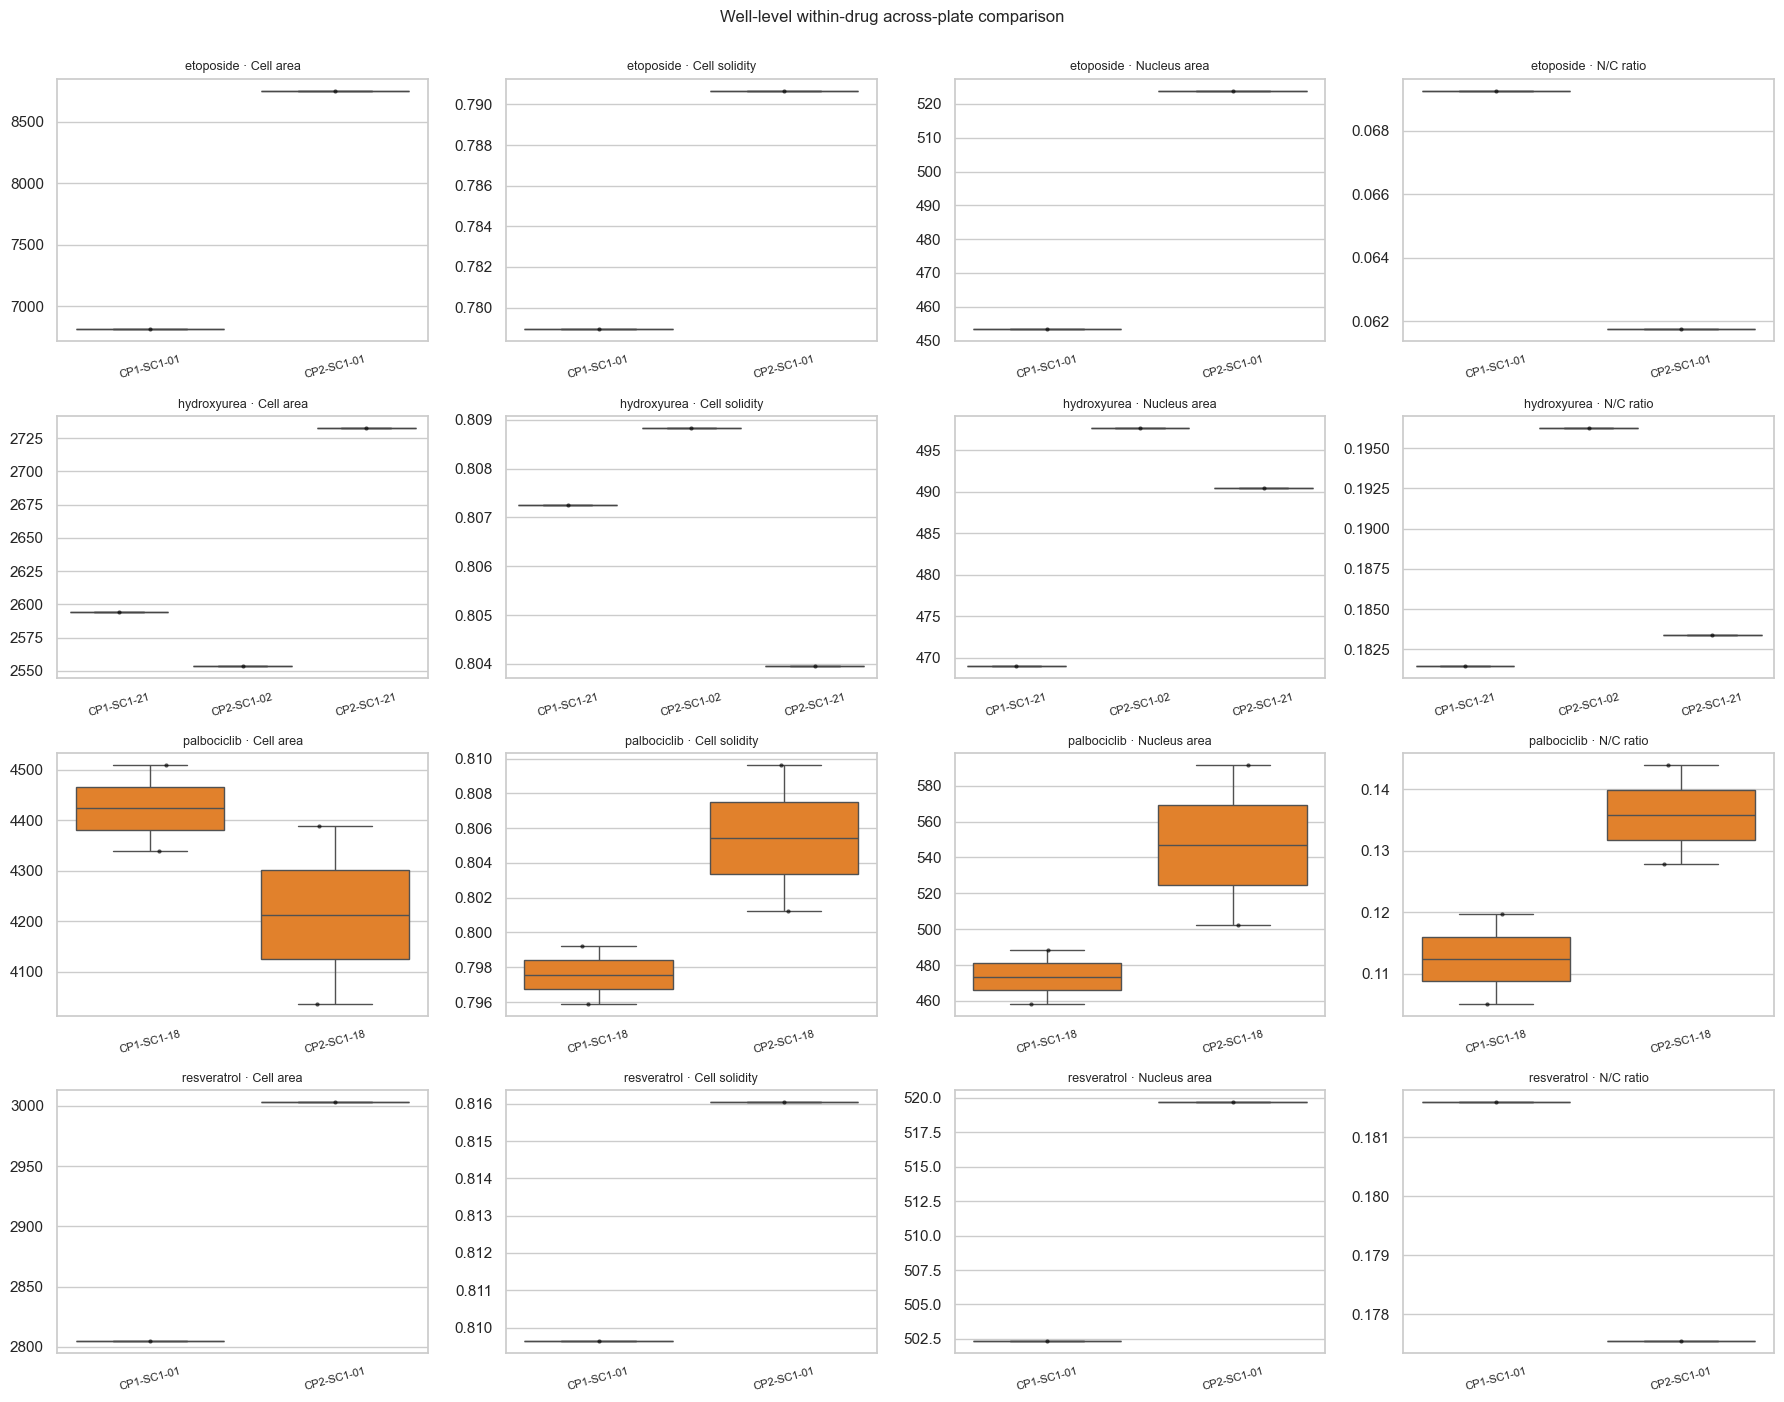

In [33]:
# --- Build a well-level dataset ---
well_df = (
    df.groupby(["Metadata_Plate", "Metadata_Well", "drug_name"], as_index=False)
      .agg(
          n_cells=("drug_name", "size"),
          **{f"{feat}_median": (feat, "median") for feat in key_features}
      )
)

print("Well-level summary:")
display(well_df.head())

feature_labels = {
    "Cells_AreaShape_BoundingBoxArea": "Cell area",
    "Cells_AreaShape_Solidity": "Cell solidity",
    "Nuclei_AreaShape_BoundingBoxArea": "Nucleus area",
    "NC_Ratio": "N/C ratio",
}

fig, axes = plt.subplots(
    len(multi_plate_drugs), len(key_features),
    figsize=(4.5 * len(key_features), 3.5 * len(multi_plate_drugs))
)

if len(multi_plate_drugs) == 1:
    axes = axes.reshape(1, -1)

for i, drug in enumerate(multi_plate_drugs):
    sub = well_df[well_df["drug_name"] == drug]
    for j, feat in enumerate(key_features):
        y_col = f"{feat}_median"

        sns.boxplot(
            data=sub,
            x="Metadata_Plate",
            y=y_col,
            ax=axes[i, j],
            color=DRUG_COLORS[drug],
            fliersize=0
        )

        sns.stripplot(
            data=sub,
            x="Metadata_Plate",
            y=y_col,
            ax=axes[i, j],
            color="black",
            size=3,
            alpha=0.65
        )

        axes[i, j].set_title(f"{drug} · {feature_labels[feat]}", fontsize=9)
        axes[i, j].set_xlabel("")
        axes[i, j].set_ylabel("")
        axes[i, j].tick_params(axis="x", rotation=15, labelsize=8)

fig.suptitle("Well-level within-drug across-plate comparison", fontsize=12, y=1.0)
plt.tight_layout()
fig.savefig(FIGURES / "per_plate_within_drug_well_level.png", dpi=180, bbox_inches="tight")
plt.show()

In [34]:
# --- quantify plate shift using well-level medians ---
well_key_cols = [f"{feat}_median" for feat in key_features]

well_plate_medians = (
    well_df.groupby(["drug_name", "Metadata_Plate"])[well_key_cols]
           .median()
           .reset_index()
)

well_plate_medians_long = well_plate_medians.melt(
    id_vars=["drug_name", "Metadata_Plate"],
    value_vars=well_key_cols,
    var_name="feature",
    value_name="plate_median"
)

well_plate_shift_summary = (
    well_plate_medians_long
    .groupby(["drug_name", "feature"])
    .agg(
        n_plates=("Metadata_Plate", "nunique"),
        min_plate_median=("plate_median", "min"),
        max_plate_median=("plate_median", "max"),
    )
    .reset_index()
)

well_plate_shift_summary["median_range_across_plates"] = (
    well_plate_shift_summary["max_plate_median"]
    - well_plate_shift_summary["min_plate_median"]
)

well_plate_shift_summary = well_plate_shift_summary.sort_values(
    "median_range_across_plates",
    ascending=False
)

print("Well-level plate shift summary:")
display(well_plate_shift_summary)

well_plate_shift_summary.to_csv(TABLES / "well_level_plate_shift_summary.csv", index=False)

Well-level plate shift summary:


,drug_name,feature,n_plates,min_plate_median,max_plate_median,median_range_across_plates
4,etoposide,Cells_AreaShape_BoundingBoxArea_median,2,6813.446250,8754.200000,1940.753750
12,palbociclib,Cells_AreaShape_BoundingBoxArea_median,2,4212.641875,4423.786250,211.144375
16,resveratrol,Cells_AreaShape_BoundingBoxArea_median,2,2804.977500,3002.707500,197.730000
8,hydroxyurea,Cells_AreaShape_BoundingBoxArea_median,3,2553.378750,2732.730000,179.351250
15,palbociclib,Nuclei_AreaShape_BoundingBoxArea_median,2,473.411250,546.926250,73.515000
7,etoposide,Nuclei_AreaShape_BoundingBoxArea_median,2,453.342500,523.900000,70.557500
11,hydroxyurea,Nuclei_AreaShape_BoundingBoxArea_median,3,468.975000,497.705000,28.730000
19,resveratrol,Nuclei_AreaShape_BoundingBoxArea_median,2,502.352500,519.675000,17.322500
14,palbociclib,NC_Ratio_median,2,0.112426,0.135868,0.023443
10,hydroxyurea,NC_Ratio_median,3,0.181435,0.196258,0.014824


The median morphology of the same drug varied to varying degrees on different plates. 
Etoposide showed the most significant cell area plate shift, while palbociclib also exhibited shifts in nucleus area and N/C ratio. 
This suggests that subsequent classifiers may be affected by plate/batch variation; however, this table only presents diagnostic results and is not a formal statistical test.

## 5. Feature correlation — check potential collinearity

We compute Pearson correlation between all feature pairs, plot a heatmap, and list pairs with |r| > 0.9 as candidates for removal.

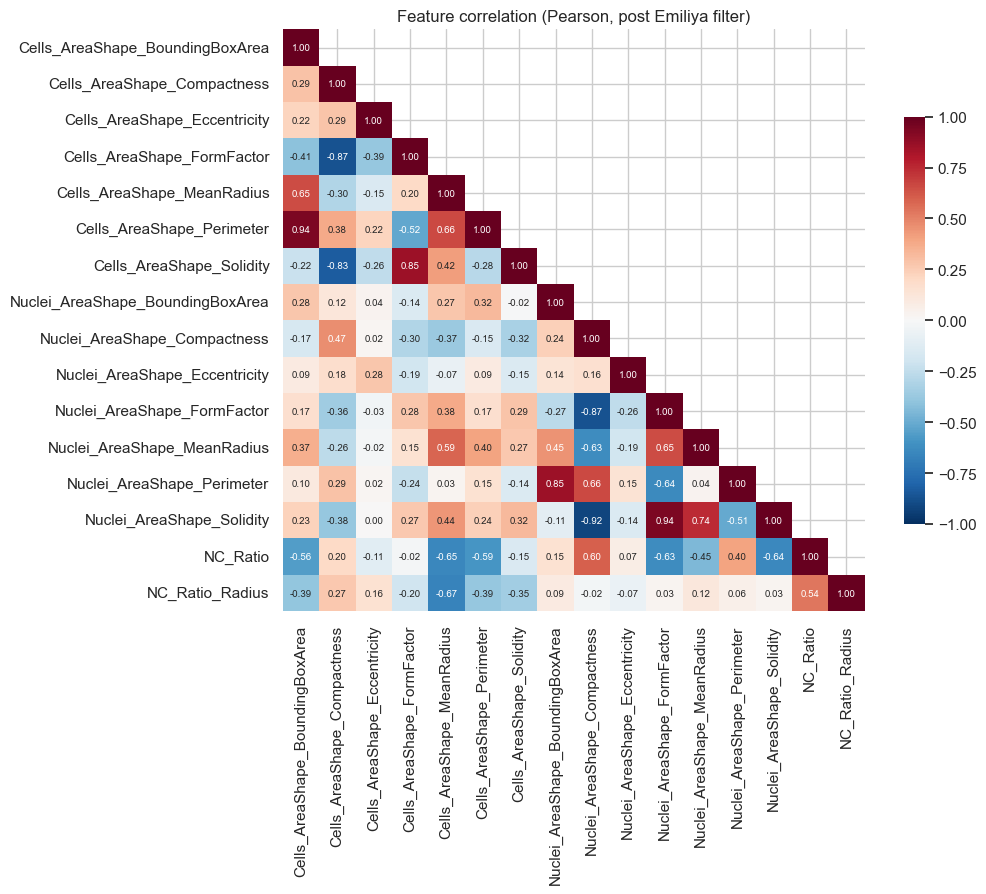


Feature pairs with |r| >= 0.9: 3


,feature_1,feature_2,r
0,Cells_AreaShape_BoundingBoxArea,Cells_AreaShape_Perimeter,0.944
2,Nuclei_AreaShape_FormFactor,Nuclei_AreaShape_Solidity,0.941
1,Nuclei_AreaShape_Compactness,Nuclei_AreaShape_Solidity,-0.917


In [7]:
corr = df[FEATURES].corr()

fig, ax = plt.subplots(figsize=(11, 9))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, mask=mask, cmap="RdBu_r", center=0, vmin=-1, vmax=1,
            annot=True, fmt=".2f", annot_kws={"fontsize": 7}, square=True, ax=ax,
            cbar_kws={"shrink": 0.7})
ax.set_title("Feature correlation (Pearson, post Emiliya filter)")
plt.tight_layout()
fig.savefig(FIGURES / "feature_correlation.png", dpi=180, bbox_inches="tight")
plt.show()

# Identify highly correlated pairs
high_corr_pairs = []
for i in range(len(FEATURES)):
    for j in range(i + 1, len(FEATURES)):
        r = corr.iloc[i, j]
        if abs(r) >= 0.9:
            high_corr_pairs.append({"feature_1": FEATURES[i], "feature_2": FEATURES[j], "r": r})

high_corr_df = pd.DataFrame(high_corr_pairs).sort_values("r", key=abs, ascending=False)
high_corr_df.to_csv(TABLES / "high_correlation_pairs.csv", index=False)
print(f"\nFeature pairs with |r| >= 0.9: {len(high_corr_df)}")
high_corr_df.round(3)


The correlation heatmap shows substantial collinearity among several morphology features. As expected, cell-size features are strongly correlated, especially cell bounding-box area and cell perimeter. Nucleus-shape features are also highly correlated, particularly nucleus form factor, compactness, and solidity.

N/C ratio is negatively correlated with cell-size features, which is consistent with the observation that treatments with enlarged cells tend to have lower nucleus-to-cell ratios.

These correlations suggest that downstream model interpretation should focus on feature groups rather than individual variables. For example, high importance for cell area, perimeter, or mean radius should be interpreted as evidence for a cell-size signal, rather than as three independent biomarkers.

## 6. Re-train Random Forest on cleaned + log-transformed features


In [8]:
# Step 1: build the cleaned feature matrix
df_cleaned = df.copy()

# Drop extreme outliers (Q3 + 3*IQR cutoff)
outlier_mask = pd.Series(False, index=df_cleaned.index)
for feat in FEATURES:
    q1, q3 = df_cleaned[feat].quantile([0.25, 0.75])
    iqr = q3 - q1
    lo, hi = q1 - 3 * iqr, q3 + 3 * iqr
    outlier_mask |= (df_cleaned[feat] < lo) | (df_cleaned[feat] > hi)

print(f"Cells before extreme-outlier removal: {len(df_cleaned):,}")
print(f"Cells flagged as extreme outliers:    {outlier_mask.sum():,} ({outlier_mask.mean()*100:.2f}%)")
df_cleaned = df_cleaned[~outlier_mask].copy()
print(f"Cells after extreme-outlier removal:  {len(df_cleaned):,}")
print(f"\nPer-drug after cleaning:")
print(df_cleaned['drug_name'].value_counts().to_string())

# Step 2: log-transform the flagged features
for feat in log_candidates:
    df_cleaned[feat] = np.log1p(df_cleaned[feat])
print(f"\nApplied log1p to: {log_candidates}")


Cells before extreme-outlier removal: 102,430
Cells flagged as extreme outliers:    15,726 (15.35%)
Cells after extreme-outlier removal:  86,704

Per-drug after cleaning:
drug_name
DMSO           74591
hydroxyurea     5601
palbociclib     3117
resveratrol     2878
etoposide        517

Applied log1p to: ['Nuclei_AreaShape_Perimeter', 'Nuclei_AreaShape_Compactness', 'Cells_AreaShape_Compactness', 'Nuclei_AreaShape_BoundingBoxArea', 'Cells_AreaShape_BoundingBoxArea', 'NC_Ratio', 'Cells_AreaShape_Perimeter']


In [9]:
# Step 3: re-train RF with the same setup as notebook 04
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GroupKFold
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, recall_score

INDUCERS = ["etoposide", "hydroxyurea", "palbociclib"]
df_train = df_cleaned[df_cleaned["drug_name"].isin(["DMSO"] + INDUCERS)].copy()
df_train["label"] = df_train["drug_name"].isin(INDUCERS).astype(int)
df_train["well_id"] = df_train["Metadata_Plate"] + "_" + df_train["Metadata_Well"]

X = df_train[FEATURES].values
y = df_train["label"].values
groups = df_train["well_id"].values

print(f"Training cells (cleaned): {len(df_train):,}, wells: {df_train['well_id'].nunique()}")
print(f"Class balance: DMSO={(y==0).sum():,}  inducer={(y==1).sum():,}")


Training cells (cleaned): 83,826, wells: 47
Class balance: DMSO=74,591  inducer=9,235


In [37]:
gkf = GroupKFold(n_splits=5)

fold_results = []
all_y_true, all_y_pred, all_y_prob = [], [], []

for fold_idx, (tr, te) in enumerate(gkf.split(X, y, groups)):
    clf = RandomForestClassifier(
        n_estimators=200, class_weight="balanced",
        random_state=42 + fold_idx, n_jobs=-1,
    )
    clf.fit(X[tr], y[tr])
    y_pred = clf.predict(X[te])
    y_prob = clf.predict_proba(X[te])[:, 1]
    acc = accuracy_score(y[te], y_pred)
    auc = roc_auc_score(y[te], y_prob)
    rec = recall_score(y[te], y_pred)
    fold_results.append({"fold": fold_idx, "accuracy": acc, "auc": auc, "inducer_recall": rec})
    all_y_true.append(y[te]); all_y_pred.append(y_pred); all_y_prob.append(y_prob)
    print(f"Fold {fold_idx}: accuracy={acc:.3f}, AUC={auc:.3f}, inducer_recall={rec:.3f}")

results_df = pd.DataFrame(fold_results)
print("\n=== Summary (cleaned features) ===")
print(f"Mean accuracy:       {results_df['accuracy'].mean():.3f} ± {results_df['accuracy'].std():.3f}")
print(f"Mean AUC:            {results_df['auc'].mean():.3f} ± {results_df['auc'].std():.3f}")
print(f"Mean inducer recall: {results_df['inducer_recall'].mean():.3f} ± {results_df['inducer_recall'].std():.3f}")

results_df.to_csv(TABLES / "rf_cleaned_per_fold.csv", index=False)


Fold 0: accuracy=0.885, AUC=0.508, inducer_recall=0.009
Fold 1: accuracy=0.941, AUC=0.743, inducer_recall=0.105
Fold 2: accuracy=0.847, AUC=0.629, inducer_recall=0.076
Fold 3: accuracy=0.847, AUC=0.632, inducer_recall=0.050
Fold 4: accuracy=0.943, AUC=0.735, inducer_recall=0.156

=== Summary (cleaned features) ===
Mean accuracy:       0.893 ± 0.048
Mean AUC:            0.649 ± 0.096
Mean inducer recall: 0.079 ± 0.055


Confusion matrix (cleaned):
                Predicted DMSO  Predicted inducer
Actual DMSO              74244                347
Actual inducer            8614                621


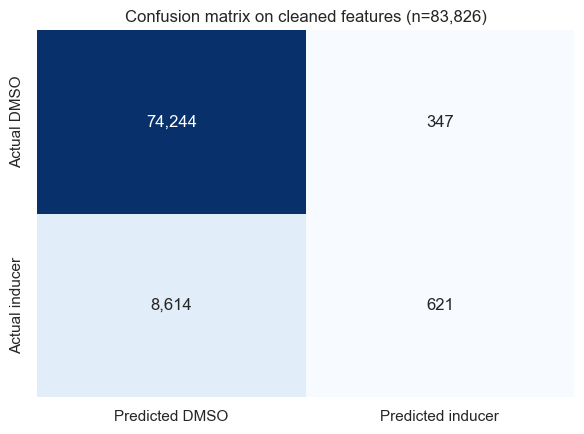

In [11]:
# Confusion matrix on the cleaned data (pooled across folds)
y_true_all = np.concatenate(all_y_true)
y_pred_all = np.concatenate(all_y_pred)
cm = confusion_matrix(y_true_all, y_pred_all)
cm_df = pd.DataFrame(cm, index=["Actual DMSO", "Actual inducer"],
                         columns=["Predicted DMSO", "Predicted inducer"])
print("Confusion matrix (cleaned):")
print(cm_df.to_string())

# Visual
fig, ax = plt.subplots(figsize=(6, 4.5))
sns.heatmap(cm_df, annot=True, fmt=",d", cmap="Blues", cbar=False, ax=ax)
ax.set_title(f"Confusion matrix on cleaned features (n={len(y_true_all):,})")
plt.tight_layout()
fig.savefig(FIGURES / "rf_cleaned_confusion.png", dpi=180, bbox_inches="tight")
plt.show()


Cleaned + log-transformed Random Forest did not improve the model; it made the model more biased towards DMSO, resulting in lower inducer recall. This suggests that aggressive outlier removal may have removed truly useful inducer morphology signals.

In [39]:
# Side-by-side comparison: baseline (notebook 04) vs cleaned (this notebook)
# Baseline numbers from notebook 04 output:
baseline = {"mean_accuracy": 0.887, "mean_auc": 0.690, "mean_inducer_recall": 10473/(10473+2054)}  # but we need to compute recall from those — actually 16.4%
baseline["mean_inducer_recall"] = 2054 / (2054 + 10473)  # TP / (TP + FN) = 2054 / 12527 = 0.164

cleaned = {
    "mean_accuracy": results_df["accuracy"].mean(),
    "mean_auc": results_df["auc"].mean(),
    "mean_inducer_recall": results_df["inducer_recall"].mean(),
}

comparison = pd.DataFrame({
    "Baseline (nb 04)": baseline,
    "Cleaned (this nb)": cleaned,
}).round(3)
comparison["(cleaned − baseline)"] = (comparison["Cleaned (this nb)"] - comparison["Baseline (nb 04)"]).round(3)
comparison.to_csv(TABLES / "rf_baseline_vs_cleaned.csv")
comparison


,Baseline (nb 04),Cleaned (this nb),(cleaned − baseline)
mean_accuracy,0.887,0.893,0.006
mean_auc,0.690,0.649,-0.041
mean_inducer_recall,0.164,0.079,-0.085


This table further illustrates that the additional extreme outlier removal + log transform should not be used as the default preprocessing; it may be removing a useful inducer signal.

## 7. Summary of this notebook
### Personal Notes:

The additional outlier removal and log transformation **did not improve the classifier**. Although raw accuracy increased slightly, AUC decreased and inducer recall dropped substantially. Because the dataset is highly imbalanced, the small increase in accuracy likely reflects the model becoming more conservative and predicting DMSO more often.

The decrease in AUC and inducer recall suggests that aggressive outlier removal may have removed biologically meaningful extreme morphology associated with inducer-treated cells. Therefore, extreme values should not be blindly removed. In this project, outliers may include both technical artifacts and genuine senescence-like morphology.

Overall, this notebook suggests that the classifier's limitations are unlikely to be solved by simple data cleaning alone. The more important issues are likely class imbalance, cell-level dependence within wells, possible plate/batch variation, and the fact that some morphology signals may be concentrated in extreme cells.

